# 04 — Economy Factors
Analyses pistol round impact and buy-type win rates by tier.
NOTE: series_economy covers ~73% T1 / ~81% T2 of working matches.


In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt

from eda.utils import load_tables, enrich_matches, get_working_matches, savefig

tables = load_tables()
matches = enrich_matches(tables['matches'])
working = get_working_matches(matches)


In [2]:
econ = tables['series_economy']
econ_w = econ.merge(working[['match_id','tier','winner_team_id']], on='match_id', how='inner')
econ_w['match_won'] = (econ_w['team_id'] == econ_w['winner_team_id']).astype(int)
print(f"Economy rows: {len(econ_w):,}")
print(econ_w['tier'].value_counts())


Economy rows: 24,860
tier
tier2    13854
tier1    11006
Name: count, dtype: int64


Match win rate by pistols won and tier:
pistols_won         0         1         2
tier                                     
tier1        0.279972  0.424220  0.573461
tier2        0.293475  0.412992  0.549426
Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/04_pistol_impact.png


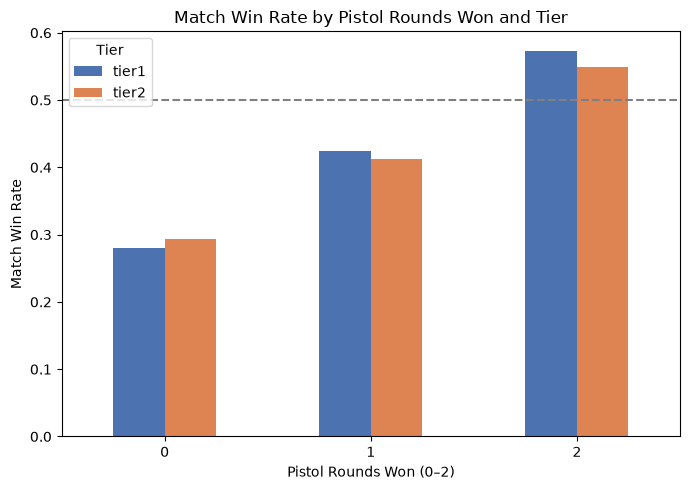

In [3]:
# 4a. Pistol impact: win rate by number of pistol rounds won
pistol_wr = econ_w.groupby(['tier','pistols_won'])['match_won'].mean().unstack()
print("Match win rate by pistols won and tier:")
print(pistol_wr.to_string())

fig, ax = plt.subplots(figsize=(7,5))
pistol_wr.T.plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452'])
ax.set_title('Match Win Rate by Pistol Rounds Won and Tier')
ax.set_xlabel('Pistol Rounds Won (0–2)')
ax.set_ylabel('Match Win Rate')
ax.axhline(0.5, color='gray', linestyle='--')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Tier')
plt.tight_layout()
savefig(fig, '04_pistol_impact')
plt.show()


Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/04_buy_type_winrate.png


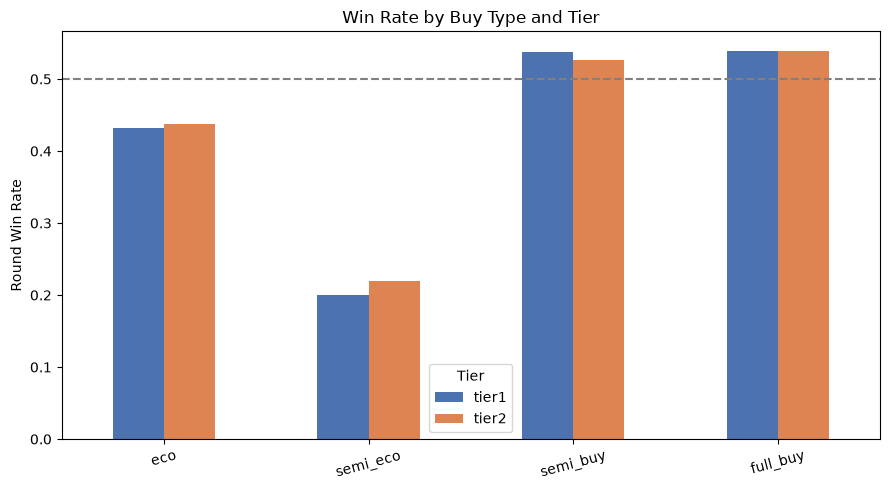

In [4]:
# 4b. Buy-type win rates
buy_types = ['eco','semi_eco','semi_buy','full_buy']
for bt in buy_types:
    econ_w[f'{bt}_winrate'] = (econ_w[f'{bt}_won'] / econ_w[f'{bt}_rounds'].replace(0, pd.NA))

bt_wr = econ_w.groupby('tier')[[f'{bt}_winrate' for bt in buy_types]].mean()
bt_wr.columns = buy_types

fig, ax = plt.subplots(figsize=(9,5))
bt_wr.T.plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452'])
ax.set_title('Win Rate by Buy Type and Tier')
ax.set_ylabel('Round Win Rate')
ax.axhline(0.5, color='gray', linestyle='--')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Tier')
plt.tight_layout()
savefig(fig, '04_buy_type_winrate')
plt.show()


Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/04_fullbuy_efficiency.png


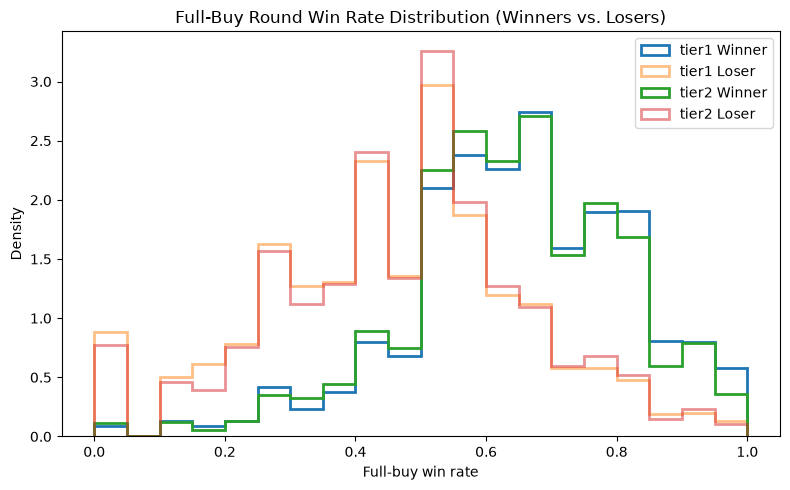

In [5]:
# 4c. Full-buy efficiency: winner vs. loser full_buy_winrate
fig, ax = plt.subplots(figsize=(8,5))
for tier in ['tier1','tier2']:
    for outcome, label, alpha in [(1,'Winner',1.0),(0,'Loser',0.5)]:
        data = (econ_w[(econ_w['tier']==tier) & (econ_w['match_won']==outcome)]
                ['full_buy_winrate'].dropna())
        ax.hist(data, bins=20, alpha=alpha, density=True,
                label=f'{tier} {label}', histtype='step', linewidth=2)
ax.set_title('Full-Buy Round Win Rate Distribution (Winners vs. Losers)')
ax.set_xlabel('Full-buy win rate')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
savefig(fig, '04_fullbuy_efficiency')
plt.show()
